# Generate
## Collocation + Synthetic Market Data for Inverse Heston PINN


In [9]:
import os
import torch
import numpy as np
import pandas as pd
from pathlib import Path


### Colab Setup


In [10]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo_url = "https://github.com/egil10/fys5429.git"
    repo_dir = "/content/fys5429"

    if not os.path.exists(repo_dir):
        !git clone {repo_url} {repo_dir}
    else:
        !git -C {repo_dir} pull

    os.chdir(os.path.join(repo_dir, "code", "notebooks"))

    import shutil
    if os.path.exists('/content/drive') and not os.path.ismount('/content/drive'):
        shutil.rmtree('/content/drive')

    from google.colab import drive
    drive.mount('/content/drive')

print(f"Working directory: {os.getcwd()}")


Already up to date.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/fys5429/code/notebooks


### Global parameters


In [11]:
torch.manual_seed(42)

# Domain
S_max = 300.0
T_max = 1.0
K = 100.0
r = 0.05

# Variance domain
v_min = 0.01
v_max = 1.0
v0 = 0.04

# TRUE Heston parameters (the answer the inverse PINN must discover)
kappa_true = 2.0
theta_true = 0.04
xi_true = 0.3
rho_true = -0.7

# Feller condition check
feller = 2 * kappa_true * theta_true
print(f"Feller check: 2*kappa*theta = {feller:.4f} > xi^2 = {xi_true**2:.4f} ? {feller > xi_true**2}")

# Point counts (same as forward Heston PINN)
N_INTERIOR = 10000
N_IC = 2000
N_BC = 1000

# NEW: Synthetic market data observations
N_DATA = 200

# Noise level for synthetic data (small Gaussian noise to simulate real-world imperfection)
NOISE_STD = 0.5

# Output
if IN_COLAB:
    out_dir = Path("/content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda")
else:
    out_dir = Path("..") / "data" / "generated"

out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "inv_collocation.parquet"


Feller check: 2*kappa*theta = 0.1600 > xi^2 = 0.0900 ? True


### Loading the Analytical Heston Solver


/tmp/ipykernel_1000/3946091143.py:46: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  int1, _ = spi.quad(heston_integrand, 1e-4, 100, args=(S0, v0, kappa, theta, xi, rho, r, tau, K, 1))
/tmp/ipykernel_1000/3946091143.py:50: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and callin

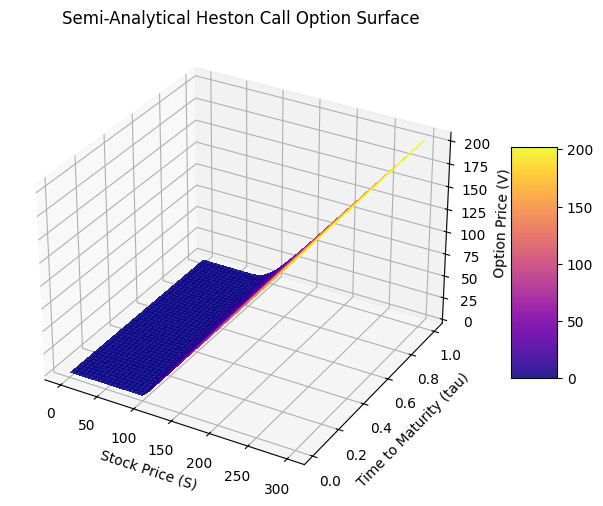

In [12]:
%run hs.ipynb


### Generating collocation data


In [13]:
def generate_collocation(S_max, T_max, K, r, v_min, v_max, v0,
                         N_interior, N_ic, N_bc):
    """
    Generate 3D collocation points (S, v, tau) with clustered sampling
    near the strike, near expiry, and near initial variance.
    """
    # ... exact same body as generate_hs.ipynb ...
    # (Copy all the interior, IC, and BC generation code)


### Generating synthetic market observations


In [14]:
def generate_collocation(S_max, T_max, K, r, v_min, v_max, v0,
                         N_interior, N_ic, N_bc):
    """
    Generate 3D collocation points (S, v, tau) with clustered sampling
    near the strike, near expiry, and near initial variance.
    """

    # --- Interior points ---
    # 40% uniform, 20% near strike, 20% near expiry, 20% near v0
    n_uniform = int(0.4 * N_interior)
    n_strike  = int(0.2 * N_interior)
    n_expiry  = int(0.2 * N_interior)
    n_v0      = N_interior - n_uniform - n_strike - n_expiry

    # Uniform across full (S, v, tau) domain
    S_uni   = torch.rand(n_uniform, 1) * S_max
    v_uni   = v_min + torch.rand(n_uniform, 1) * (v_max - v_min)
    tau_uni = torch.rand(n_uniform, 1) * T_max

    # Clustered near strike: S ~ Normal(K, 0.2*K)
    S_strike   = (K + 0.2 * K * torch.randn(n_strike, 1)).clamp(0, S_max)
    v_strike   = v_min + torch.rand(n_strike, 1) * (v_max - v_min)
    tau_strike = torch.rand(n_strike, 1) * T_max

    # Clustered near expiry: tau ~ Beta(0.5, 2) * T_max
    S_expiry   = torch.rand(n_expiry, 1) * S_max
    v_expiry   = v_min + torch.rand(n_expiry, 1) * (v_max - v_min)
    tau_expiry = torch.distributions.Beta(0.5, 2.0).sample((n_expiry, 1)) * T_max

    # Clustered near initial variance v0: v ~ Normal(v0, 0.3*v0)
    S_v0   = torch.rand(n_v0, 1) * S_max
    v_v0   = (v0 + 0.3 * v0 * torch.randn(n_v0, 1)).clamp(v_min, v_max)
    tau_v0 = torch.rand(n_v0, 1) * T_max

    S_interior   = torch.cat([S_uni,   S_strike,   S_expiry,   S_v0],   dim=0)
    v_interior   = torch.cat([v_uni,   v_strike,   v_expiry,   v_v0],   dim=0)
    tau_interior = torch.cat([tau_uni, tau_strike, tau_expiry, tau_v0], dim=0)

    # --- IC points (tau=0) ---
    n_ic_uni    = N_ic // 2
    n_ic_clust  = N_ic - n_ic_uni

    S_ic = torch.cat([
        torch.rand(n_ic_uni, 1) * S_max,
        (K + 0.15 * K * torch.randn(n_ic_clust, 1)).clamp(0, S_max)
    ], dim=0)
    v_ic = torch.cat([
        v_min + torch.rand(n_ic_uni, 1) * (v_max - v_min),
        (v0 + 0.3 * v0 * torch.randn(n_ic_clust, 1)).clamp(v_min, v_max)
    ], dim=0)
    tau_ic = torch.zeros(N_ic, 1)

    # --- BC points: 4 boundaries ---
    n_per_bc = N_bc // 4

    # 1) S = 0 (lower S): V(0, v, tau) = 0
    S_bc_s_lower   = torch.zeros(n_per_bc, 1)
    v_bc_s_lower   = v_min + torch.rand(n_per_bc, 1) * (v_max - v_min)
    tau_bc_s_lower = torch.rand(n_per_bc, 1) * T_max

    # 2) S = S_max (upper S)
    S_bc_s_upper   = torch.full((n_per_bc, 1), S_max)
    v_bc_s_upper   = v_min + torch.rand(n_per_bc, 1) * (v_max - v_min)
    tau_bc_s_upper = torch.rand(n_per_bc, 1) * T_max

    # 3) v = v_min (lower v boundary)
    n_bc_v_lower   = n_per_bc
    S_bc_v_lower   = torch.rand(n_bc_v_lower, 1) * S_max
    v_bc_v_lower   = torch.full((n_bc_v_lower, 1), v_min)
    tau_bc_v_lower = torch.rand(n_bc_v_lower, 1) * T_max

    # 4) v = v_max (upper v boundary)
    n_bc_v_upper   = N_bc - 3 * n_per_bc
    S_bc_v_upper   = torch.rand(n_bc_v_upper, 1) * S_max
    v_bc_v_upper   = torch.full((n_bc_v_upper, 1), v_max)
    tau_bc_v_upper = torch.rand(n_bc_v_upper, 1) * T_max

    return {
        'S_interior': S_interior, 'v_interior': v_interior, 'tau_interior': tau_interior,
        'S_ic': S_ic, 'v_ic': v_ic, 'tau_ic': tau_ic,
        'S_bc_s_lower': S_bc_s_lower, 'v_bc_s_lower': v_bc_s_lower, 'tau_bc_s_lower': tau_bc_s_lower,
        'S_bc_s_upper': S_bc_s_upper, 'v_bc_s_upper': v_bc_s_upper, 'tau_bc_s_upper': tau_bc_s_upper,
        'S_bc_v_lower': S_bc_v_lower, 'v_bc_v_lower': v_bc_v_lower, 'tau_bc_v_lower': tau_bc_v_lower,
        'S_bc_v_upper': S_bc_v_upper, 'v_bc_v_upper': v_bc_v_upper, 'tau_bc_v_upper': tau_bc_v_upper,
    }


In [15]:
out_dir.mkdir(parents=True, exist_ok=True)


### Save to Parquet


In [16]:
# Generate collocation data (physics)
data = generate_collocation(S_max, T_max, K, r, v_min, v_max, v0,
                            N_INTERIOR, N_IC, N_BC)

# Generate synthetic market observations (data)
market = generate_market_data(S_max, T_max, K, r, v0, v_min, v_max,
                              kappa_true, theta_true, xi_true, rho_true,
                              N_DATA, NOISE_STD)

df_all = pd.concat([
    # Interior points (for PDE residual)
    pd.DataFrame({
        'S': data['S_interior'].numpy().flatten(),
        'v': data['v_interior'].numpy().flatten(),
        'tau': data['tau_interior'].numpy().flatten(),
        'V_data': np.nan,
        'point_type': 'interior'
    }),
    # IC points (for initial condition)
    pd.DataFrame({
        'S': data['S_ic'].numpy().flatten(),
        'v': data['v_ic'].numpy().flatten(),
        'tau': data['tau_ic'].numpy().flatten(),
        'V_data': np.nan,
        'point_type': 'initial_condition'
    }),
    # BC: S=0 lower boundary
    pd.DataFrame({
        'S': data['S_bc_s_lower'].numpy().flatten(),
        'v': data['v_bc_s_lower'].numpy().flatten(),
        'tau': data['tau_bc_s_lower'].numpy().flatten(),
        'V_data': np.nan,
        'point_type': 'boundary_S_lower'
    }),
    # BC: S=S_max upper boundary
    pd.DataFrame({
        'S': data['S_bc_s_upper'].numpy().flatten(),
        'v': data['v_bc_s_upper'].numpy().flatten(),
        'tau': data['tau_bc_s_upper'].numpy().flatten(),
        'V_data': np.nan,
        'point_type': 'boundary_S_upper'
    }),
    # BC: v=v_min lower boundary
    pd.DataFrame({
        'S': data['S_bc_v_lower'].numpy().flatten(),
        'v': data['v_bc_v_lower'].numpy().flatten(),
        'tau': data['tau_bc_v_lower'].numpy().flatten(),
        'V_data': np.nan,
        'point_type': 'boundary_v_lower'
    }),
    # BC: v=v_max upper boundary
    pd.DataFrame({
        'S': data['S_bc_v_upper'].numpy().flatten(),
        'v': data['v_bc_v_upper'].numpy().flatten(),
        'tau': data['tau_bc_v_upper'].numpy().flatten(),
        'V_data': np.nan,
        'point_type': 'boundary_v_upper'
    }),
    # NEW: Market observation points (for data loss)
    pd.DataFrame({
        'S': market['S_data'].numpy().flatten(),
        'v': market['v_data'].numpy().flatten(),
        'tau': market['tau_data'].numpy().flatten(),
        'V_data': market['V_data'].numpy().flatten(),
        'point_type': 'market_data'
    }),
], ignore_index=True)

df_all.to_parquet(out_path)
print(f"Saved to {out_path}")
print(df_all['point_type'].value_counts())
print(f"\nS range:   [{df_all['S'].min():.2f}, {df_all['S'].max():.2f}]")
print(f"v range:   [{df_all['v'].min():.4f}, {df_all['v'].max():.4f}]")
print(f"tau range: [{df_all['tau'].min():.2f}, {df_all['tau'].max():.2f}]")
print(f"Market data points: {len(df_all[df_all['point_type'] == 'market_data'])}")


Generated 200 synthetic market observations
  S range:   [51.32, 249.55]
  v range:   [0.0111, 0.4990]
  tau range: [0.0529, 0.9970]
  V range:   [0.0000, 152.8329]
  Noise std: 0.5
Saved to /content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda/inv_collocation.parquet
point_type
interior             10000
initial_condition     2000
boundary_S_lower       250
boundary_S_upper       250
boundary_v_lower       250
boundary_v_upper       250
market_data            200
Name: count, dtype: int64

S range:   [0.00, 300.00]
v range:   [0.0100, 1.0000]
tau range: [0.00, 1.00]
Market data points: 200


/tmp/ipykernel_1000/2057522529.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([
